#### Exploratory analysis of processed bulk RNA-seq **FPKM** expression data

- database: GEO 

- species: Homo Sapiens

- title: RNA Sequencing Analysis of villus tissues from unexplained recurrent spontaneous abortion patients and controls with induced abortions

- experiment type: Expression profiling by high throughput sequencing

- filename: **GSE121950_Processed_data.xlsx**


#### 1)  Downloading the file:

file has been download within the bash command link with wget method and stored in the local repository RNA_Seq/dataset/raw/filename.xlsx

After that I have wrote:

find *.tar | xargs -I {} | tar -xf {} 

With this, i pick up the single .tar file which is the only one in this subdir. pass it into the placeholder {} and passed tar -xvf filename.tar (for the uncompressed tar)



#### 2) Navigating the file path in the python (Also can be done with **Path** module, I use **os**)

In [17]:
file_name = 'GSE121950_Processed_data.xlsx'

In [18]:
import os
from pathlib import Path
import pandas as pd
curr_dir = os.getcwd()

In [19]:
print(curr_dir)
root_dir = Path("/home/skeja/RNA_seq")

/home/skeja/RNA_seq/src/bulk_rna_SEQ_FPKM


I can't traverse from this directory because it has only this file now, and dataset is in the upper dir.


#### Now i am at the root folder. I can traverse from here top -> bottom:

In [20]:
for root,dirs,files in os.walk(root_dir):
    for dir in dirs:
        if dir == 'raw':
            dir_path = os.path.join(root,dir)
print(dir_path)
# find the filename that we unpacked

for root,dirs,files in os.walk(dir_path):
    for file in  files:
        file_path = os.path.join(root,file)

print(file_path)


/home/skeja/RNA_seq/dataset/raw
/home/skeja/RNA_seq/dataset/raw/GSE121950_Processed_data.xlsx


In [21]:
df1 = pd.read_excel(file_path)

In [22]:
# Check if the file has multiple sheets inside

check_sheets = pd.ExcelFile(file_path)
print(check_sheets.sheet_names)

['cufflinks']


#### 1 sheet only, get back to df now

In [23]:
print(f'Columns: {list(df1.columns.ravel())}\nShape of the data: {df1.shape}')
print(df1.head())

Columns: ['GeneName', 'locus', '21-E2_FPKM', '24-E1_FPKM', '37-E2_FPKM', '63-E2_FPKM', '70-E2_FPKM', '74-E2_FPKM']
Shape of the data: (110816, 8)
     GeneName                      locus  21-E2_FPKM  24-E1_FPKM  37-E2_FPKM  \
0      CUFF.1           chr1:11868-14412    0.159062    0.792676    0.131641   
1     CUFF.10         chr1:840486-841186    0.151860    3.969010    0.000000   
2    CUFF.100       chr1:5937157-5967232    0.112714    1.544550  156.482000   
3   CUFF.1000     chr1:41369015-41383172    0.000000    4.945570    0.162266   
4  CUFF.10000  chr12:105312623-105312955    0.000000    0.380248    0.000000   

   63-E2_FPKM  70-E2_FPKM  74-E2_FPKM  
0    0.218518    0.115030    0.108970  
1    0.847498    1.634930    0.325581  
2    0.000000    4.159060    0.848227  
3    0.000000   11.765600    0.000000  
4    0.000000    0.513219    2.210200  


#### This dataset represents **processed** bulk RNA-seq FPKM expression matrix

#### 3) Splitting annotation matrix from expression matrix:

- annot table: [ GeneName, Locus]

- expression table: [ 21-E2_FPKM...]

In [24]:
annot_cols = ["GeneName","locus"]
expression_cols = [col for col in df1 if str(col).endswith('_FPKM')]

In [25]:
annotation = df1[annot_cols]
expression = df1[expression_cols]

In [26]:
expression_cols = expression.columns
expression_cols_clean = [cols[:5] for cols in expression_cols] # cleaning up the column names

In [27]:
expression.columns = expression_cols_clean

In [28]:
expression

,21-E2,24-E1,37-E2,63-E2,70-E2,74-E2
0,0.159062,0.792676,0.131641,0.218518,0.115030,0.108970
1,0.151860,3.969010,0.000000,0.847498,1.634930,0.325581
2,0.112714,1.544550,156.482000,0.000000,4.159060,0.848227
3,0.000000,4.945570,0.162266,0.000000,11.765600,0.000000
4,0.000000,0.380248,0.000000,0.000000,0.513219,2.210200
...,...,...,...,...,...,...
110811,0.000000,0.000000,0.000000,0.000000,0.114808,0.000000
110812,0.000000,0.028088,0.066568,0.109918,0.050095,0.000000
110813,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
110814,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### 4) Making of **metadata** table

In [29]:
metadata = pd.DataFrame({
    "sample":[col for col in expression_cols_clean],
    "condition":["control", "control", "control", "RSA", "RSA", "RSA"]
})

In [30]:
metadata

,sample,condition
0,21-E2,control
1,24-E1,control
2,37-E2,control
3,63-E2,RSA
4,70-E2,RSA
5,74-E2,RSA


#### 5) Filtering out low expressed genes

- Higher the FPKM of the gene, higher is the expression


1. FPKM > 1 indicates the "Active" genes

2. This will help to filter out the noise and inactive genes

3. Treshold will be set as FPKM > 1 in at least 2 samples (6 samples total)

By this I will keep genes, that are active in at least 2 different samples .

In [31]:
min_fpkm = 1
min_samples = 2

expression_filtered = expression[(expression>min_fpkm).sum(axis=1)>=min_samples]

In [32]:
expression_filtered

,21-E2,24-E1,37-E2,63-E2,70-E2,74-E2
1,0.151860,3.96901,0.000000,0.847498,1.634930,0.325581
2,0.112714,1.54455,156.482000,0.000000,4.159060,0.848227
3,0.000000,4.94557,0.162266,0.000000,11.765600,0.000000
5,0.000000,0.13400,0.322318,2.276680,0.116094,2.849930
6,0.000000,0.00000,0.934429,9.850350,0.376569,1.058990
...,...,...,...,...,...,...
110572,0.000000,5.13826,0.000000,4.554010,1.150240,0.000000
110608,1.314580,3.84714,3.164110,2.089430,1.403500,2.354090
110637,1.703520,5.13707,3.860770,2.123640,1.745020,0.000000
110655,0.000000,0.00000,0.000000,1.441140,0.000000,2.263410


In [33]:
expression_filtered.min()
expression_filtered.mean()
expression_filtered.max()

21-E2     19098.6
24-E1     10673.5
37-E2     41665.7
63-E2     27143.7
70-E2    173596.0
74-E2     42261.3
dtype: float64

In [34]:
expression_filtered.describe()

,21-E2,24-E1,37-E2,63-E2,70-E2,74-E2
count,33026.000000,33026.000000,33026.000000,33026.000000,33026.000000,33026.000000
mean,10.874957,17.732165,20.098178,17.351515,18.575959,19.596919
std,134.726242,155.047347,331.471701,212.945471,962.705448,298.809554
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.290462,0.000000,0.000000,0.000000,0.000000
50%,0.199436,1.014215,0.538192,0.686266,1.009445,0.969256
75%,2.301225,4.610358,4.588468,3.952357,4.824248,4.753180
max,19098.600000,10673.500000,41665.700000,27143.700000,173596.000000,42261.300000


<Axes: ylabel='Count'>

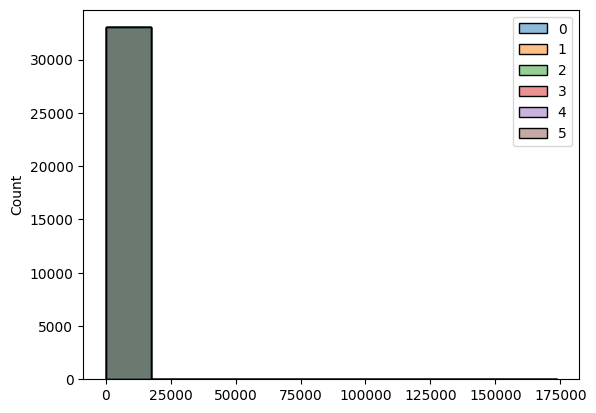

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(expression_filtered.values,bins=10)

Not so informative

In [36]:
import numpy as np

# make a log transformation of the data

log_expression = np.log2(expression_filtered + 1)

In [37]:
log_expression

,21-E2,24-E1,37-E2,63-E2,70-E2,74-E2
1,0.203965,2.312958,0.000000,0.885573,1.397765,0.406625
2,0.154083,1.347411,7.299043,0.000000,2.367108,0.886142
3,0.000000,2.571815,0.216940,0.000000,3.674189,0.000000
5,0.000000,0.181421,0.403069,1.712235,0.158459,1.944832
6,0.000000,0.000000,0.951908,3.439670,0.461077,1.041937
...,...,...,...,...,...,...
110572,0.000000,2.617830,0.000000,2.473530,1.104498,0.000000
110608,1.210750,2.277134,2.058008,1.627341,1.265137,1.745921
110637,1.434839,2.617550,2.281185,1.643228,1.456817,0.000000
110655,0.000000,0.000000,0.000000,1.287555,0.000000,1.706380


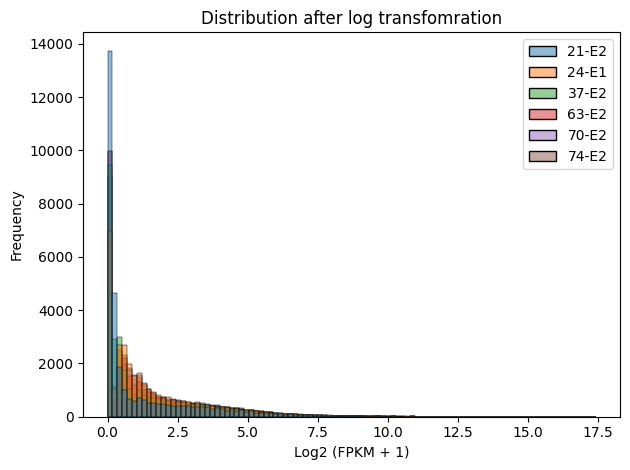

In [38]:
sns.histplot(log_expression,bins=100)
plt.xlabel('Log2 (FPKM + 1)')
plt.title('Distribution after log transfomration')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Lets inspect the heat map of correlation

<Axes: >

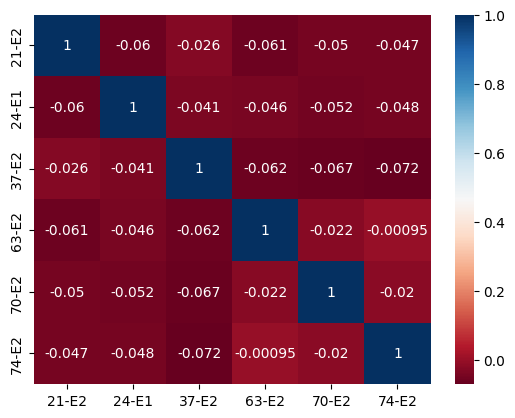

In [39]:
sns.heatmap(log_expression.corr(),cmap='RdBu',annot=True)

#### For the RNA Seq data, especially from the same tissue (villi), we expect to see that all samples have positive correlation.

#### Heatmap - > takes each column as one sample, and compares - > 21-E2 vs 24-E1 , 21 - E2 vs 37-E2 ... 

#### For each pair - > If one transcript expression is high, is it high also in the compared sample?


#### It is indeed strange that there is no correlation between these samples 


#### This means no linear dependence between samples!



In [40]:
expression_filtered

,21-E2,24-E1,37-E2,63-E2,70-E2,74-E2
1,0.151860,3.96901,0.000000,0.847498,1.634930,0.325581
2,0.112714,1.54455,156.482000,0.000000,4.159060,0.848227
3,0.000000,4.94557,0.162266,0.000000,11.765600,0.000000
5,0.000000,0.13400,0.322318,2.276680,0.116094,2.849930
6,0.000000,0.00000,0.934429,9.850350,0.376569,1.058990
...,...,...,...,...,...,...
110572,0.000000,5.13826,0.000000,4.554010,1.150240,0.000000
110608,1.314580,3.84714,3.164110,2.089430,1.403500,2.354090
110637,1.703520,5.13707,3.860770,2.123640,1.745020,0.000000
110655,0.000000,0.00000,0.000000,1.441140,0.000000,2.263410


#### Control sample comparison: **21-E2** vs **24-E1**



In [41]:
log_expression['21-E2']

1         0.203965
2         0.154083
3         0.000000
5         0.000000
6         0.000000
            ...   
110572    0.000000
110608    1.210750
110637    1.434839
110655    0.000000
110682    0.620389
Name: 21-E2, Length: 33026, dtype: float64

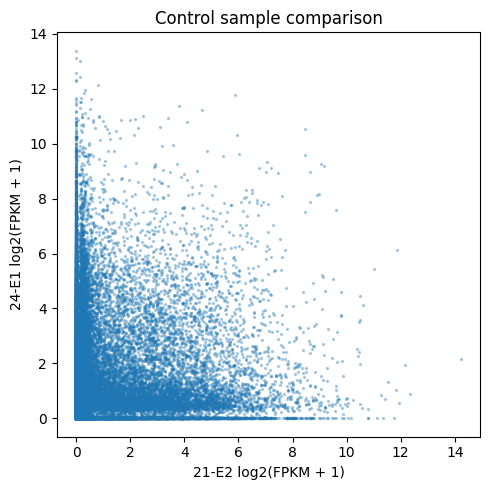

In [42]:
plt.figure(figsize=(5, 5))

plt.scatter(
    log_expression["21-E2"],
    log_expression["24-E1"],
    s=2,
    alpha=0.3
)

plt.xlabel("21-E2 log2(FPKM + 1)")
plt.ylabel("24-E1 log2(FPKM + 1)")
plt.title("Control sample comparison")
plt.tight_layout()
plt.show()

#### Dataset may be sparse, it has a lot of rows, and many of them may be 0 (lets check that)

In [43]:
zeros = (expression==0).mean(axis=0) * 100
print(zeros)

21-E2    60.099625
24-E1    57.621643
37-E2    60.082479
63-E2    65.020394
70-E2    64.881425
74-E2    63.858107
dtype: float64


In [44]:
expressed_per_sample = (expression>1).sum(axis=0)
print(f"expressed_per_sample:\n {expressed_per_sample}\nFPKM expresion per sample:\n {expression.sum(axis=0)}")


expressed_per_sample:
 21-E2    14397
24-E1    20092
37-E2    17498
63-E2    16719
70-E2    19275
74-E2    18697
dtype: int64
FPKM expresion per sample:
 21-E2    493556.952757
24-E1    722874.807372
37-E2    804489.590739
63-E2    643140.167020
70-E2    713325.859363
74-E2    750656.124192
dtype: float64


In [45]:
### FPKM > 0.8
### min_samples > 3

expression = expression[(expression>1).sum(axis=1)>=3]
expression_new_log = np.log2(expression+1)

<Axes: >

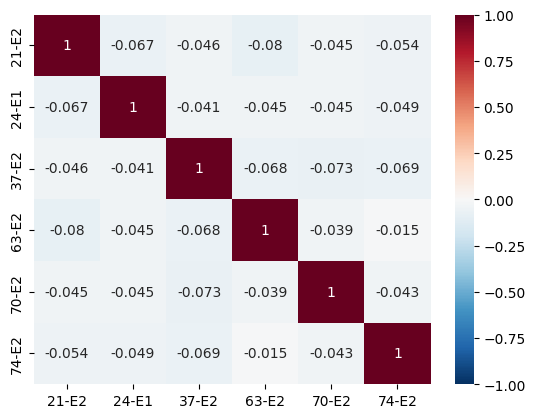

In [46]:
sns.heatmap(
    expression_new_log.corr(),
    annot=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0
)

##### Based on the exploratory analysis, the processed FPKM matrix showed unexpectedly low sample-to-sample correlations, even between biological replicates. Therefore, this processed dataset in its current form may not be suitable for strong biological interpretation without further validation or access to raw count data.